# 0. Installation

## Install the NEST simulator through conda
Install condacolab.

In [ ]:
!pip install -q condacolab
import condacolab
condacolab.install()


📢 Announcement 📢
condacolab==0.2 will be released soon! Try it with:

    !pip install -q https://github.com/conda-incubator/condacolab/archive/main.zip
    import condacolab
    condacolab.install()

0.2.x introduces a new installation method based on Pixi, with customizable Python versions.
This may be breaking for your workflow. If that's the case, please report it at
https://github.com/conda-incubator/condacolab and pin your `pip install` command to
condacolab==0.1 as a workaround.

✨🍰✨ Everything looks OK!


Install NEST through conda.

In [ ]:
!mamba install -y -c conda-forge nest-simulator cmake compilers libboost-headers "sysroot_linux-64<2.34"

[+] 0.0s
[+] 0.0s
[+] 0.1s
conda-forge/linux-64  ⣾  
conda-forge/noarch    ⣾  [+] 0.2s
conda-forge/linux-64   2%
conda-forge/noarch     1%[+] 0.3s
conda-forge/linux-64   4%
conda-forge/noarch     3%[+] 0.4s
conda-forge/linux-64   5%
conda-forge/noarch     4%[+] 0.5s
conda-forge/linux-64   6%
conda-forge/noarch     9%[+] 0.6s
conda-forge/linux-64   8%
conda-forge/noarch    11%[+] 0.7s
conda-forge/linux-64   9%
conda-forge/noarch    13%[+] 0.8s
conda-forge/linux-64  10%
conda-forge/noarch    17%[+] 0.9s
conda-forge/linux-64  14%
conda-forge/noarch    24%[+] 1.0s
conda-forge/linux-64  17%
conda-forge/noarch    31%[+] 1.1s
conda-forge/linux-64  18%
conda-forge/noarch    33%[+] 1.2s
conda-forge/linux-64  21%
conda-forge/noarch    38%[+] 1.3s
conda-forge/linux-64  24%
conda-forge/noarch    41%[+] 1.4s
conda-forge/linux-64  24%
conda-forge/noarch    45%[+] 1.5s
conda-forge/linux-64  25%
conda-forge/noarch    46%[+] 1.6s
conda-forge/linux-64  28%
conda-forge/noarch    51%[+] 1.7s
conda-forge/l

## Link this notebook to your Google Drive


This cell will open a pop up window in which Google will ask you to which Google Drive
account you want to link this notebook, so that the files you produce end up in your Drive instead of being lost when the Colab runtime is recycled.

In [1]:
from google.colab import drive, output

drive.mount("/content/drive", force_remount=True)
output.enable_custom_widget_manager()

Mounted at /content/drive


Create (or reuse) a working folder inside your Drive and move into it

In [2]:
from os import makedirs, chdir, listdir
from os.path import join

ROOT_FOLDER = "/content/drive/MyDrive/Colab Notebooks/fit_eglif_model"
makedirs(ROOT_FOLDER, exist_ok=True)
chdir(ROOT_FOLDER)

TRACES_FOLDER = join(ROOT_FOLDER, "traces_neuron")
RESULTS_FOLDER = join(ROOT_FOLDER, "results")
makedirs(RESULTS_FOLDER, exist_ok=True)

## Install BSB and cerebellar-models

Install BSB and cerebellar-cortex, it will ask you to restart your session, do so !

In [3]:
!pip install -r requirements.txt

  Cloning https://github.com/dbbs-lab/bsb.git (to revision next) to /tmp/pip-install-dqfwdg2a/arborize_ce4dfc06741e428cbfa111aec9fa31f6
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/bsb.git /tmp/pip-install-dqfwdg2a/arborize_ce4dfc06741e428cbfa111aec9fa31f6
  Running command git checkout -b next --track origin/next
  Switched to a new branch 'next'
  branch 'next' set up to track 'origin/next'.
  Resolved https://github.com/dbbs-lab/bsb.git to commit 1beda4404d128382680698d56435bb79ebb65f17
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Cloning https://github.com/dbbs-lab/bsb.git (to revision next) to /tmp/pip-install-dqfwdg2a/nrn-patch_24addaa3a4434581804c9b10188cf069
  Running command git clone --filter=blob:none --quiet https://github.com/dbbs-lab/bsb.git /tmp/pip-install-dqfwdg2a/nrn-patch_24addaa3a4434581804c9b10188cf069
  Running command git checkout -b n

Compile NESTML models

In [4]:
!cerebellar-models build-nestml

Building NESTML models...

             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.

The computation had not completed because of the undecidable set membership is found in every candidates.
CMake Warning:
  Ignoring empty string ("") provided on the command line.


-- The CXX compiler identification is GNU 15.2.0
-- Detecting CXX compiler ABI info
-- Detecting CXX compiler ABI info - done
--

# 1. Fitting / optimization NEST eglif model given neural traces from a set of current injection protocols
## Loading and plotting traces from current injection steps

In [5]:
%matplotlib inline
%env MPLBACKEND=Agg

env: MPLBACKEND=Agg


In [6]:
import numpy as np
import pickle
import json
import nest
import matplotlib.pyplot as plt
from scipy.optimize import differential_evolution

from optimization.features import multicomp_features, point_neuron_features
from optimization.fitness import (
    rheobase_loss, currents_above_thr, curvature_loss,
    gap_loss, _fi_curve, slope_loss
)
from optimization.utils import load_experiments_files, run_nest_batch, reset_nest, nest_single_sim
from optimization.plotting import plot_fi_curve, plot_raster, plot_experiment_traces


             -- N E S T --

 Copyright (C) 2004 The NEST Initiative

 Version: 3.10.0
 Built  : Jun 12 2026 10:07:47

 This program is provided AS IS and comes with NO WARRANTY.
 See the file LICENSE for details.

 Problems or suggestions?
   Visit https://www.nest-simulator.org

 Type 'nest.help()' to find out more about NEST.



In [7]:
# Load experiment protocols
with open(join(TRACES_FOLDER, "protocols.json"), 'r') as file:
    protocols = json.load(file)

# Load protocol and traces for specific cell type
cell_type = "GrC"
protocol = protocols[cell_type]
print(f"Protocol: {json.dumps(protocol, indent=4)}")

traces, inj_currents = load_experiments_files(
    join(TRACES_FOLDER, cell_type),
    stim_start = protocol["stim_start"],
    stim_end = protocol["stim_end"]
)
print(
  f"First trace:\n\t{str(traces[0]).replace(",", ",\n")},\n\t"
  f"injected_current: {inj_currents[0]}"
)

Protocol: {
    "stim_start": 100.0,
    "stim_end": 600.0,
    "duration": 700.0,
    "threshold": -41
}
curr:  -6.0
curr:  -4.0
curr:  -2.0
curr:  0.0
curr:  2.0
curr:  4.0
curr:  6.0
curr:  8.0
curr:  10.0
curr:  12.0
curr:  14.0
curr:  16.0
curr:  18.0
curr:  20.0
First trace:
	{'T': array([0.00000e+00,
 2.50000e-02,
 5.00000e-02,
 ...,
 6.99950e+02,

       6.99975e+02,
 7.00000e+02]),
 'V': array([-80.        ,
 -79.89360702,
 -79.79931932,
 ...,
 -65.15756041,

       -65.1575547 ,
 -65.15754899]),
 'stim_start': [100.0],
 'stim_end': [600.0]},
	injected_current: -6.0


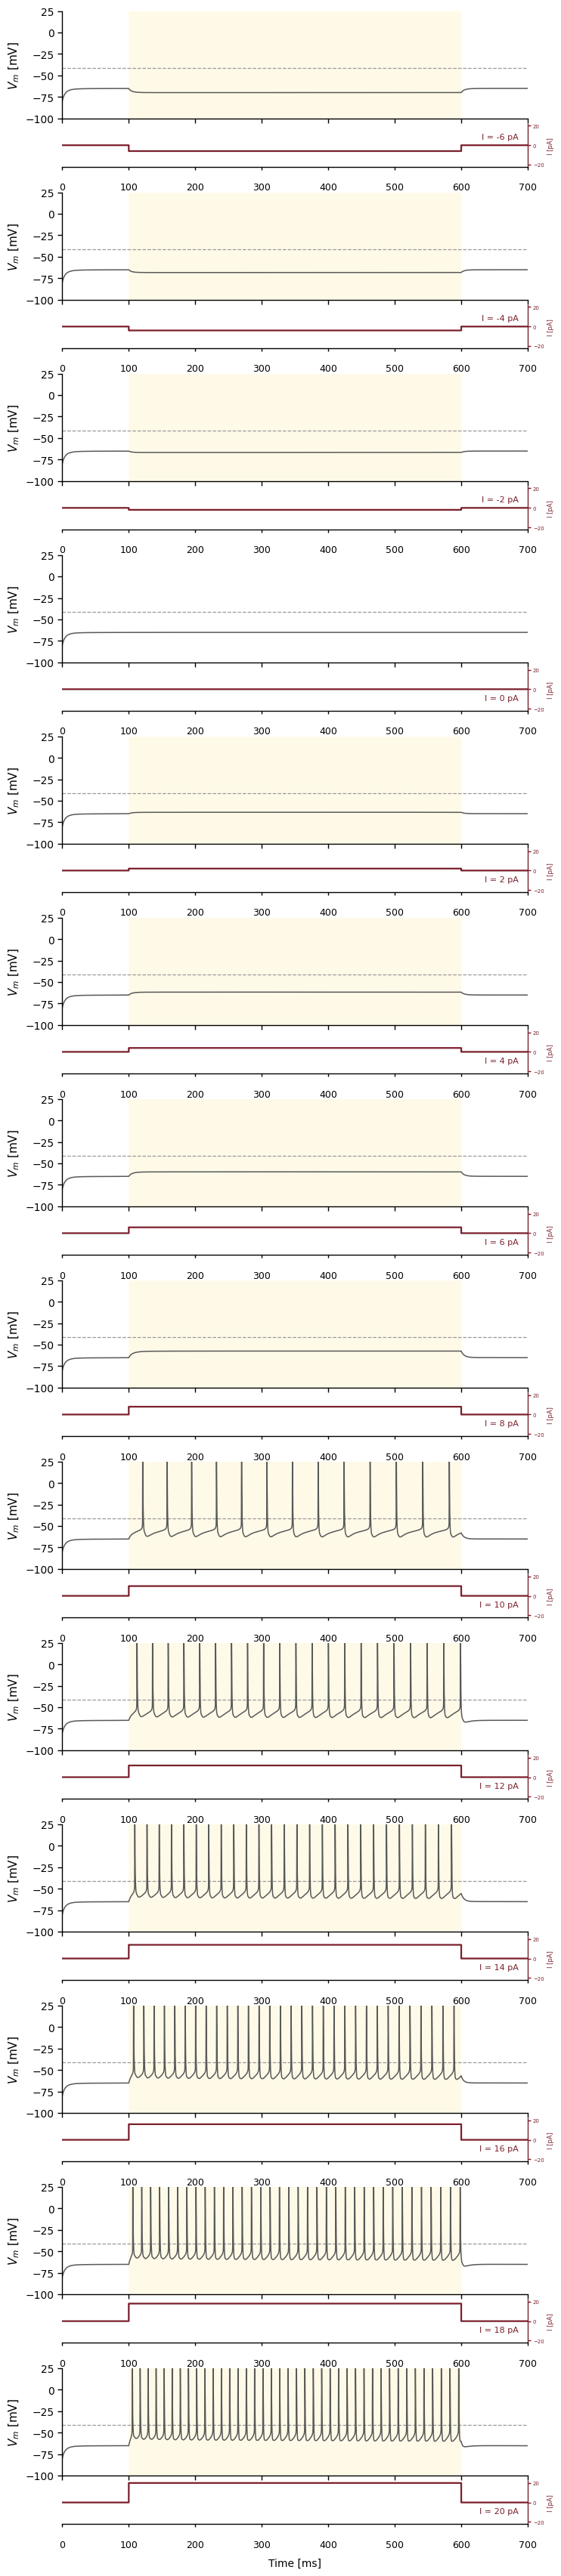

In [8]:
fig = plot_experiment_traces(traces, protocols[cell_type], inj_currents)
fig.show()
fig.savefig(
    join(RESULTS_FOLDER, cell_type, "experiment_traces.png"),
    dpi=700, bbox_inches="tight"
)

## Computing features from experimental traces: [efel](https://efel.readthedocs.io/en/stable/eFeatures.html) tool

In [9]:
neuron_features = multicomp_features(
    traces,
    inj_currents,
    threshold = protocol["threshold"]
)
neuron_features.keys()

/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating peak_time, An error occurred while computing the feature, feature is not found. Voltage never goes below or above threshold in spike detection.
/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating time_to_first_spike, An error occurred while computing the feature, feature is not found. Voltage never goes below or above threshold in spike detection.
/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating time_to_second_spike, An error occurred while computing the feature, feature is not found. Voltage never goes below or above threshold in spike detection.
/usr/local/lib/python3.13/site-packages/efel/pyfeatures/cppfeature_access.py:14: RuntimeWarning:Error while calculating time_to_last_spike, An error occurred while computing the feature, 

Index(['current', 'peak_time', 'time_to_first_spike', 'time_to_second_spike',
       'time_to_last_spike', 'inv_first_ISI', 'inv_second_ISI',
       'inv_third_ISI', 'inv_fourth_ISI', 'inv_fifth_ISI', 'inv_last_ISI',
       'ISI_log_slope', 'ISI_CV', 'adaptation_index', 'spike_count_stimint',
       'mean_frequency'],
      dtype='str')

## NEST eglif model
The model consists of a set of 3 differential equations describing the time evolution of:

1) **Membrane Potential** ($V_m$)
2) **Adaptation Current** ($I_{adap}$): reproduces the activation of potassium channels, generating a slow hyperpolarizing current;
3) **Depolarization Current** ($I_{dep}$): acts as a spike-triggered depolarizing current, mimicking the fast activation of sodium channels;


<h2 style="font-size: 25px;">
Model Equations
</h2>

The E-GLIF model is described by a system of 3 coupled linear ordinary differential equations:

$$
\begin{cases}
\dfrac{dV_m(t)}{dt} = \dfrac{1}{C_m}\left(\dfrac{C_m}{\tau_m}\big(V_m(t)-E_L\big) - I_{adap}(t) + I_{dep}(t) + I_e + I_{stim}\right) \\[8pt]
\dfrac{dI_{adap}(t)}{dt} = k_{adap}\big(V_m(t)-E_L\big) - k_2 \cdot I_{adap}(t) \\[8pt]
\dfrac{dI_{dep}(t)}{dt} = -k_1 \cdot I_{dep}(t)
\end{cases}
$$

where:
- $I_{stim}$ - external stimulation current
- $C_m$ - membrane capacitance
- $\tau_m$ - membrane time constant
- $E_L$ - resting potential
- $I_e$ - endogenous current (accounts for autorhythmicity)
- $k_{adap}, k_2$ - adaptation constants
- $k_1$ - $I_{dep}$ decay rate

**Spike generation:** if the neuron is not in the refractory period $\tau_{ref}$, a spike is generated at time $t_{spk}$.

**Update rules (post-spike reset):**

$$
\begin{cases}
V_m(t_{spk}^+) = V_r \\
I_{adap}(t_{spk}^+) = I_{adap}(t_{spk}) + A_2 \\
I_{dep}(t_{spk}^+) = A_1
\end{cases}
$$

where $V_r$ is the reset potential, and $A_1$, $A_2$ are the model currents' update (step) constants applied after each spike.

- **Fixed parameters** (directly measured neurophysiological quantities): $C_m, \tau_m, E_L, \tau_{ref}, V_{th}, V_r$.
- **Tunable parameters** (optimized for each specific cell type): $k_{adap}, k_2, k_1, A_1, A_2, I_e$.

/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
SetStatus() is deprecated and will be removed in a future version of NEST. Instead of SetStatus(nrns|conns, args), use nrns|conns.set(args).


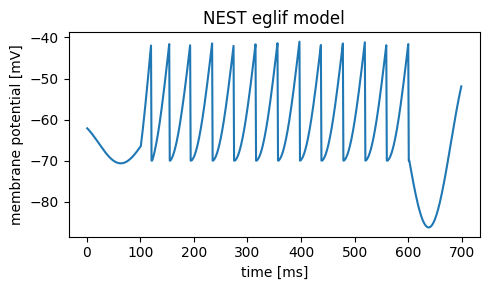

/usr/local/lib/python3.13/site-packages/nest/lib/hl_api_helper.py:111: UserWarning:
GetStatus() is deprecated and will be removed in a future version of NEST. Instead of GetStatus(nrns|conns, args), use nrns|conns.get(args).


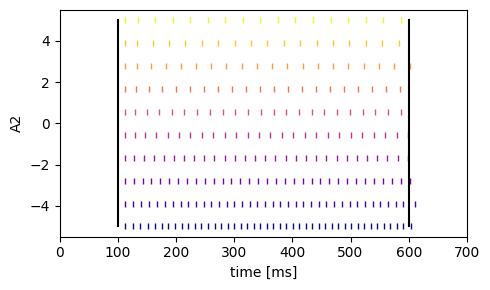

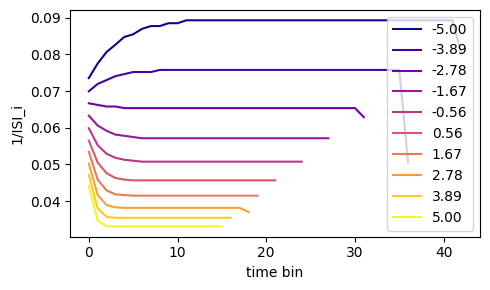

In [10]:
# NEST eglif model
nest_model = "eglif_multirec"
# Load eglif init parameters
with open(join(TRACES_FOLDER, "neuron_params.json"), 'r') as file:
    cell_params = json.load(file)[cell_type]

test_cell_params = cell_params.copy()

# Current injection
reset_nest()
inj_current = 6.0 #pA
vr = nest_single_sim(nest_model, inj_current, protocol, test_cell_params, output='voltage')
nest.Simulate(protocol["duration"])
Vms = vr.events["V_m"]
ts = vr.events["times"]

fig, ax = plt.subplots(figsize=(5,3))
ax.plot(ts, Vms)
ax.set_xlabel('time [ms]')
ax.set_ylabel('membrane potential [mV]')
ax.set_title('NEST eglif model')
plt.tight_layout()
plt.show()

# Explore role of k_adapt, k_2, A2
# Prepare a batch of single cell simulations to run together for parameter exploration
test_cell_params = cell_params.copy()
reset_nest()
vars = np.linspace(-5.0, 5.0, 10) #np.linspace(0.001, 0.01, 10) #np.linspace(0.01, 0.08, 10)
var_name = 'A2' #'k_2' #'k_adap'
inj_current = 12.0 #pA
nest_recorders = {}
for var_i in vars:
  test_cell_params[var_name] = var_i
  nest_recorders[var_i] = nest_single_sim(nest_model, inj_current, protocol, test_cell_params)

# Simulate and extract results
nest.Simulate(protocol["duration"])
spike_trains = []
spike_trains += [nest.GetStatus(sr, "events")[0]["times"] for sr in nest_recorders.values()]

# Plotting raster
import matplotlib as mpl
cmap = mpl.colormaps['plasma']
colors = cmap(np.linspace(0, 1, len(vars)))

fig_r, ax_r = plt.subplots(figsize=(5,3))
ax_r.set_facecolor("white")
fig_f, ax_f = plt.subplots(figsize=(5,3))
ax_f.set_facecolor("white")

for i, var_i in enumerate(vars):
  ax_r.plot(spike_trains[i], np.repeat(var_i, len(spike_trains[i])), '|', color=colors[i], markersize=4)
  ax_f.plot(1./np.diff(spike_trains[i]), color=colors[i], label=(f'{var_i:.2f}'))

ax_r.set_xlabel('time [ms]')
ax_r.set_ylabel(var_name)
ax_r.set_xlim([0, protocol['duration']])
ax_r.plot([protocol['stim_start'], protocol['stim_start']], [np.min(vars), np.max(vars)], '-k')
ax_r.plot([protocol['stim_end'], protocol['stim_end']], [np.min(vars), np.max(vars)], '-k')
plt.figure(fig_r)
plt.tight_layout()

ax_f.set_xlabel('time step')
ax_f.set_ylabel('1/ISI_i')
ax_f.legend()
plt.figure(fig_f)
plt.tight_layout()

## Repeat same current step injection protocol in NEST and extract same features

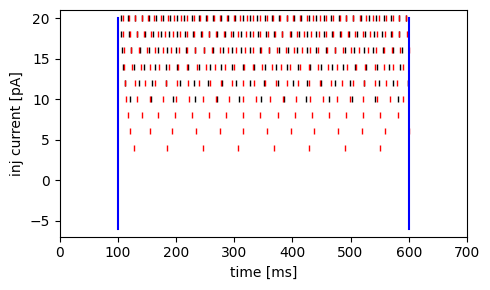

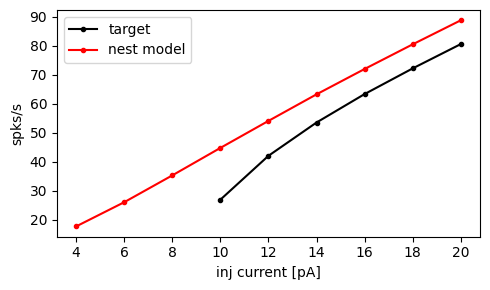

In [11]:
# nest eglif simulations
spike_trains = run_nest_batch(nest_model, inj_currents, protocol, cell_params)
orig_nest_features = point_neuron_features(
    spike_trains = spike_trains,
    currents = inj_currents,
    stim_start = protocol["stim_start"],
    stim_end = protocol["stim_end"],
)

makedirs(join(RESULTS_FOLDER, cell_type), exist_ok=True)
# Raster plot
fig = plot_raster(neuron_features, orig_nest_features, inj_currents, protocol)
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'init_raster.png'), dpi=700, bbox_inches="tight")

# FI curve
fig = plot_fi_curve(neuron_features, orig_nest_features, labels=["target", "nest model"])
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'init_fI.png'), dpi=700, bbox_inches="tight")

# Define the objective function of the optimization problem

In [ ]:
# 1. Rheobase error: min current to emit spike
rheo, thr = rheobase_loss(orig_nest_features, neuron_features)
sel = currents_above_thr(neuron_features, thr)
# 2. Slope error: weighed (by sqrt current) median of fI slope
slope = slope_loss(neuron_features, orig_nest_features, thr, sel)
# 3. Difference between fI curve curvatures
curv = curvature_loss(neuron_features, orig_nest_features, sel, use_max_slope_penalty=True)
# 4. Mean absolute error between fI curves
gap = gap_loss(neuron_features, orig_nest_features, sel, weighted="gaussian")

print(f"Rheobase error: {rheo}")
print(f"Slope error: {slope}")
print(f"Curvature error: {curv}")
print(f"Gap error: {gap}")

Rheobase error: 0.37499999999999994
Slope error: 0.10306982343511344
Curvature error: 0.3908999920431643
Gap error: 0.23735805324337325


In [ ]:
def cell_obj_function(x, target_features, protocol, cell_params, nest_model="eglif_multirec"):
    # set NEST params
    loc_cell_params = cell_params.copy()
    loc_cell_params['I_e'] = x[0]
    loc_cell_params['k_adap'] = x[1]
    loc_cell_params["k_1"] = x[2]
    loc_cell_params["A1"] = x[3]
    loc_cell_params["A2"] = x[4]

    inj_currents = target_features["current"].values
    spike_trains = run_nest_batch(nest_model, inj_currents, protocol, loc_cell_params)
    nest_features = point_neuron_features(
        spike_trains = spike_trains,
        currents = inj_currents,
        stim_start = protocol["stim_start"],
        stim_end = protocol["stim_end"],
    )
    # Define the objective function
    # 1. Rheobase error: min current to emit spike
    rheo, thr = rheobase_loss(nest_features, target_features)
    sel = currents_above_thr(target_features, thr)
    # 2. Slope error: weighed (by sqrt current) median of fI slope
    slope = slope_loss(target_features, nest_features, thr, sel)
    # 3. Difference between fI curve curvatures
    curv = curvature_loss(target_features, nest_features, sel, use_max_slope_penalty=True)
    # 4. Mean absolute error between fI curves
    gap = gap_loss(target_features, nest_features, sel, weighted="gaussian")

    if np.any(np.isnan([rheo, slope, curv, gap])):
        return 4.0
    return np.sum([rheo, slope, curv, gap])

## Set opt problem

In [ ]:
# Initial values
x0 = [
    cell_params['I_e'],
    cell_params['k_adap'],
    cell_params['k_1'],
    cell_params['A1'],
    cell_params['A2']
]

# Define which variables to optimize of the EGLIF model and set their bounds
bounds = [
    (-5.0, -2.0),   # I_e
    (0.01, 0.5),    # k_adap
    (0.01, 5.0),    # k_1
    (0.01, 40.0),   # A1
    (-10.0, 10.0),  # A2
]

# Solving optimization: differential_evolution from scipy.optimize is an
# evolutionary algorithm (not based on gradient) that updates a condidate
# solution by combining existing ones
res = differential_evolution(
    cell_obj_function,
    bounds=bounds,
    args=(neuron_features, protocol, cell_params),
    strategy='best1bin',
    maxiter=int(1e3),
    popsize=2,
    mutation=(0.5, 1.0),
    recombination=0.7,
    rng=42,
    # workers=1,           # Uses all available CPU cores (-1)
    # updating="deferred"   # Processes whole generations in parallel
)

/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:227: RuntimeWarning:Degrees of freedom <= 0 for slice
/usr/local/lib/python3.13/dist-packages/numpy/_core/_methods.py:219: RuntimeWarning:invalid value encountered in scalar divide
/usr/local/lib/pytho

In [ ]:
# Show results
print(
    "I_e: ", res.x[0],
    "\nk_adap: ", res.x[1],
    "\nk_1: ", res.x[2],
    "\nA1: ", res.x[3],
    "\nA2: ", res.x[4],
    "\n\nFinal loss:",  res.fun
)

I_e:  -3.2670938596002115 
k_adap:  0.03980629163615529 
k_1:  1.8984385660957894 
A1:  18.130509252582673 
A2:  -2.479732298129572 

Final loss: 0.3168584064136047


# Evaluate solution

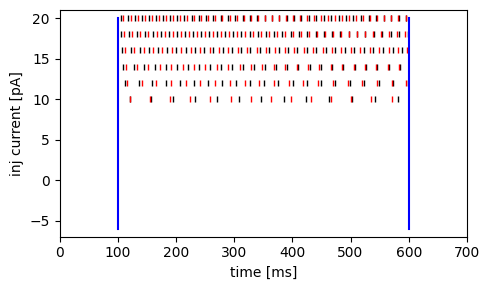

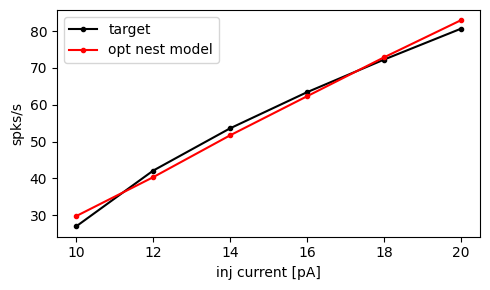

In [ ]:
# NEST opt params
cell_params_opt = cell_params.copy()
cell_params_opt['I_e'] = res.x[0]
cell_params_opt['k_adap'] = res.x[1]
cell_params_opt["k_1"] = res.x[2]
cell_params_opt["A1"] = res.x[3]
cell_params_opt["A2"] = res.x[4]

# Repeat current step injection protocol in NEST on the optimal solution
spike_trains = run_nest_batch(nest_model, inj_currents, protocol, cell_params_opt)
nest_features_opt = point_neuron_features(
    spike_trains = spike_trains,
    currents = inj_currents,
    stim_start = protocol["stim_start"],
    stim_end = protocol["stim_end"],
)

# Raster plot
fig = plot_raster(neuron_features, nest_features_opt, inj_currents, protocol)
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'opt_raster.png'), dpi=700, bbox_inches="tight")

# Inspect fI curves
fig = plot_fi_curve(neuron_features, nest_features_opt, labels=["target", "opt nest model"])
fig.show()
fig.savefig(join(RESULTS_FOLDER, cell_type, 'opt_fI.png'), dpi=700, bbox_inches="tight")

In [ ]:
# Save results
pickle.dump({'res': res,
              'cell_params_opt': cell_params_opt
              },
            open(join(RESULTS_FOLDER, cell_type, 'opt_res.pickle'), 'wb'),
            protocol = pickle.HIGHEST_PROTOCOL
)